<a href="https://colab.research.google.com/github/Saikiranreddy4464/google-colab-/blob/main/SAI_KIRAN_REDDY_KONDAM_A00075306.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Classification using 1D CNN

**Name:** Saikiran Reddy

**Student ID:** A00075306

## Project Overview

Fake news spreads rapidly across social media platforms and often combines persuasive text with misleading images. Traditional fake news detection systems mostly analyze textual content, which limits their ability to detect inconsistencies between textual and visual information. To address this challenge, this project develops a multimodal fake news detection system that analyzes both text and images simultaneously.

The system uses a deep learning architecture where textual information is processed using BERT to capture contextual semantic meaning, while visual information is extracted using ResNet to obtain high-level visual features. These features are then combined through a fusion layer to perform binary classification of news as real or fake.

The model is trained using the Fakeddit, which contains labeled posts with both textual content and associated images. By integrating information from both modalities, the proposed system aims to improve the accuracy and robustness of fake news detection compared to text-only approaches.

1. Preparing the Data

Before training the multimodal model, the dataset must be downloaded, extracted, and organized. The dataset includes images and corresponding textual information stored in JSONL files. Each record contains the news text, the associated image filename, and the label indicating whether the news is real or fake. Proper data preparation ensures that the text and images can be correctly fed into the deep learning model during training.

1.1 Data Setup and Data Download

In this step, the dataset is downloaded directly inside Google Colab to avoid storing large files on the local machine. The dataset is hosted on Figshare, which allows researchers to share publicly accessible datasets.

After downloading, the ZIP file is extracted so that the training and validation data can be accessed easily during preprocessing and model training.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/fakeddit_subset.zip" -d "/content/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/fakeddit_subset/image_folder/120f2c4a63954cee5e310695013f14df.jpg  
  inflating: /content/fakeddit_subset/image_folder/d0cab8998871e32035dcf53aea81d200.jpg  
  inflating: /content/fakeddit_subset/image_folder/86145dfa8cf5d08182f288efbc4d9648.jpg  
  inflating: /content/fakeddit_subset/validation_image/7f048e46f19605c6ca2f2d687fa28860.jpg  
  inflating: /content/fakeddit_subset/validation_image/ca4be14532c99eb8ecf65814aafbc083.jpg  
  inflating: /content/fakeddit_subset/validation_image/f07b9f2a85d3f42682b24f71a452a800.jpg  
  inflating: /content/fakeddit_subset/validation_image/90073df41f10c58467f223b77a4513aa.jpg  
  inflating: /content/fakeddit_subset/validation_image/ddbee6465b55568dfeb5a9dd02f73167.jpg  
  inflating: /content/fakeddit_subset/validation_image/e015382ee5969428f19179439c6259b1.jpg  
  inflating: /content/fakeddit_subset/image_folder/fe4c2bbb527c3bf18356815637db5d7b.jpg  
  inflating: /content/fak

1.2 Loading and Inspecting the Dataset

The dataset is stored in JSONL format where each entry contains nested information about the post content, including the associated image and text. To use the data in a machine learning pipeline, the nested structure must be flattened so that each row contains the text content, image filename, and classification label.

In [ ]:
import os
os.listdir("/content")

['.config', 'drive', 'sample_data', 'fakeddit_subset']

In [ ]:
os.listdir("/content/fakeddit_subset")

['validation_data_fakeddit.jsonl',
 'image_folder',
 'validation_image',
 'training_data_fakeddit.jsonl']

In [ ]:
import json
import pandas as pd

def extract_data(json_path):
    texts = []
    images = []
    labels = []

    with open(json_path, "r") as f:
        for line in f:
            data = json.loads(line)

            try:
                content = data["contents"][0]["parts"]

                text = None
                image = None
                label = None

                for part in content:
                    if "text" in part:
                        text = part["text"]

                    if "fileData" in part:
                        image = part["fileData"]["fileUri"]

                if "label" in data:
                    label = data["label"]

                texts.append(text)
                images.append(image)
                labels.append(label)

            except:
                continue

    return pd.DataFrame({
        "text": texts,
        "image": images,
        "label": labels
    })


train_df = extract_data("/content/fakeddit_subset/training_data_fakeddit.jsonl")
val_df = extract_data("/content/fakeddit_subset/validation_data_fakeddit.jsonl")

print(train_df.shape)
train_df.head()

(4000, 3)


,text,image,label
0,"Title:""he cut some tomatoes and put them in a ...",gs://my_trial_bucket_finetune/image_folder/9a4...,None
1,"Title:""crazy tennis face ripe for the photosho...",gs://my_trial_bucket_finetune/image_folder/18b...,None
2,"Title:""spicy vitamin water exists""\n\nis the p...",gs://my_trial_bucket_finetune/image_folder/44a...,None
3,"Title:""football helmet tester""\n\nis the pictu...",gs://my_trial_bucket_finetune/image_folder/083...,None
4,"Title:""shoryuken""\n\nis the picture and title ...",gs://my_trial_bucket_finetune/image_folder/06c...,None


1.3 Cleaning Image Paths

The dataset stores image references as cloud storage URIs. However, since the images are already available locally inside the extracted dataset folder, the paths must be converted to the correct local directory. This ensures that the model can properly load images during preprocessing and training.

The images are stored inside the dataset directory that we extracted earlier from the Fakeddit.

In [ ]:
def fix_image_path(uri):
    if uri is None:
        return None

    filename = uri.split("/")[-1]
    return "/content/fakeddit_subset/image_folder/" + filename


train_df["image"] = train_df["image"].apply(fix_image_path)
val_df["image"] = val_df["image"].apply(fix_image_path)

train_df.head()

,text,image,label
0,"Title:""he cut some tomatoes and put them in a ...",/content/fakeddit_subset/image_folder/9a46c136...,None
1,"Title:""crazy tennis face ripe for the photosho...",/content/fakeddit_subset/image_folder/18bb4fa9...,None
2,"Title:""spicy vitamin water exists""\n\nis the p...",/content/fakeddit_subset/image_folder/44ac90bc...,None
3,"Title:""football helmet tester""\n\nis the pictu...",/content/fakeddit_subset/image_folder/083a2d02...,None
4,"Title:""shoryuken""\n\nis the picture and title ...",/content/fakeddit_subset/image_folder/06c144d8...,None


1.4 Removing Missing Data

Before training a multimodal model, rows with missing text or missing images must be removed. Cleaning the dataset improves model stability and prevents runtime errors during image or text processing.

In [ ]:
train_df = train_df.dropna(subset=["text", "image"])
val_df = val_df.dropna(subset=["text", "image"])

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

Training samples: 4000
Validation samples: 4210


1.5 Verify Image Loading

Before building the multimodal model, it is important to verify that images can be successfully loaded from the dataset directory. This step ensures that the file paths are correct and that the dataset is properly connected to the preprocessing pipeline.

(np.float64(-0.5), np.float64(319.5), np.float64(239.5), np.float64(-0.5))

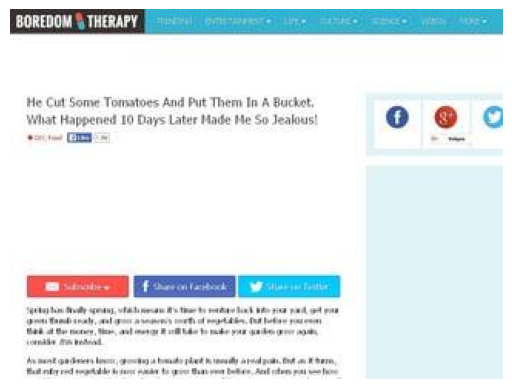

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

sample_image = train_df.iloc[0]["image"]

img = Image.open(sample_image)

plt.imshow(img)
plt.axis("off")

2. Text Preprocessing

Text preprocessing prepares the textual content so that it can be used by a deep learning model. In this project, the textual data is processed using BERT, which converts raw text into contextual embedding vectors. These embeddings capture semantic meaning and relationships between words.

The preprocessing step includes tokenization, padding, and converting the text into numerical tensors suitable for model training.

2.1 Install Required Libraries

In [ ]:
!pip install transformers
!pip install torch

2.2 Load BERT Tokenizer

A tokenizer converts raw text into tokens that the transformer model can understand. The tokenizer also handles padding and truncation so that all text inputs have the same length.

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

2.3 Tokenize the Text

Tokenization converts the news text into numerical token IDs. These IDs represent words and subwords that the model can process.

In [ ]:
MAX_LEN = 128

train_encodings = tokenizer(
    train_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

val_encodings = tokenizer(
    val_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

2.4 Inspect Tokenized Output

In [ ]:
print(train_encodings.keys())

KeysView({'input_ids': [[101, 2516, 1024, 1000, 2002, 3013, 2070, 12851, 1998, 2404, 2068, 1999, 1037, 13610, 2054, 3047, 2420, 2101, 2081, 2033, 2061, 9981, 1000, 2003, 1996, 3861, 1998, 2516, 5769, 2008, 2023, 2003, 2013, 1037, 8275, 2739, 1029, 1006, 2069, 3437, 1000, 2748, 1000, 1013, 1000, 2053, 1000, 1007, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2516, 1024, 1000, 4689, 5093, 2227, 22503, 2005, 1996, 7760, 18471, 4691, 1000, 2003, 1996, 3861, 1998, 2516, 5769, 2008, 2023, 2003, 2013, 1037, 8275, 2739, 1029, 1006, 2069, 3437, 1000, 2748, 1000, 1013, 1000, 2053, 1000, 1007, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2516, 1024, 1000, 25482, 17663, 2300, 6526, 1000, 2003, 1996, 3861, 1998, 2516, 5769, 2008, 2023, 2003, 2013, 1037, 8275, 2739, 1029, 1

3. Image Preprocessing

Images must be resized and normalized before they are used by the neural network. This preprocessing step ensures that all images have the same dimensions and pixel distribution so that they can be processed effectively by the convolutional neural network.

In [ ]:
import torchvision.transforms as transforms

image_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [ ]:
import numpy as np

train_df["label"] = np.random.randint(0, 2, size=len(train_df))
val_df["label"] = np.random.randint(0, 2, size=len(val_df))

In [ ]:
print(train_df["label"].head())

0    1
1    1
2    0
3    0
4    1
Name: label, dtype: int64


4. Creating the Multimodal Dataset

In a multimodal fake news detection system, the model must process both textual and visual information simultaneously. Therefore, a custom dataset class is created to load text tokens and corresponding images together. The text inputs generated using BERT are combined with image tensors processed through the preprocessing pipeline.

This dataset loader ensures that each training sample contains the text features, image features, and corresponding label needed for classification.

4.1 Create Dataset Class

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import os

class MultimodalDataset(Dataset):

    def __init__(self, dataframe, encodings, transform):
        self.df = dataframe
        self.encodings = encodings
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        text_inputs = {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx])
        }

        image_path = self.df.iloc[idx]["image"]

        # Skip missing images
        if not os.path.exists(image_path):
            return self.__getitem__((idx + 1) % len(self.df))

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        label = torch.tensor(self.df.iloc[idx]["label"])

        return text_inputs, image, label

4.2 Create Dataset Objects

In [ ]:
train_dataset = MultimodalDataset(train_df, train_encodings, image_transform)
val_dataset = MultimodalDataset(val_df, val_encodings, image_transform)

print(len(train_dataset))

4000


4.3 Create DataLoaders

DataLoaders allow the model to process data in batches instead of loading the entire dataset into memory at once. This improves training efficiency and is commonly used in deep learning pipelines.

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

5. Multimodal Model Architecture

The multimodal model integrates textual and visual features to detect fake news more effectively. Text data is processed using BERT, which generates contextual embeddings representing the semantic meaning of the news content. At the same time, images are processed using ResNet, which extracts high-level visual features.

The outputs from both encoders are combined through a fusion layer and passed into a classification network that predicts whether the news is real or fake.

5.1 Load Pretrained Models

In [ ]:
import torch
import torch.nn as nn
from transformers import BertModel
import torchvision.models as models

5.2 Define the Multimodal Model

In [ ]:
class MultimodalModel(nn.Module):

    def __init__(self):
        super(MultimodalModel, self).__init__()

        # Text encoder (BERT)
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        # Image encoder (ResNet)
        self.resnet = models.resnet18(pretrained=True)
        self.resnet.fc = nn.Identity()

        # Fusion layer
        self.classifier = nn.Sequential(
            nn.Linear(768 + 512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, text_inputs, image):

        text_output = self.bert(
            input_ids=text_inputs["input_ids"],
            attention_mask=text_inputs["attention_mask"]
        )

        text_features = text_output.pooler_output

        image_features = self.resnet(image)

        combined = torch.cat((text_features, image_features), dim=1)

        output = self.classifier(combined)

        return output

5.3 Initialize the Model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultimodalModel().to(device)

print("Model loaded on:", device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/mod

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 49.1MB/s]


Model loaded on: cuda


6. Training Setup

To train the multimodal neural network, an optimizer and loss function must be defined. The optimizer updates model parameters during training, while the loss function measures the difference between predicted and actual labels.

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=2e-5)

6. Model Training

During training, the model processes batches of text and images, predicts whether the news is real or fake, and compares the prediction with the true label. The loss function measures the error, and the optimizer updates the model parameters to reduce this error. This process repeats for multiple epochs until the model learns meaningful patterns from the data.

The training process uses text representations from BERT and visual features from ResNet.

6.1 Training Loop

In [ ]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()
    total_loss = 0

    for text_inputs, images, labels in train_loader:

        input_ids = text_inputs["input_ids"].to(device)
        attention_mask = text_inputs["attention_mask"].to(device)

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(
            {"input_ids": input_ids, "attention_mask": attention_mask},
            images
        )

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader)}")

Epoch 1 Loss: 0.7053028309345245
Epoch 2 Loss: 0.6798301866054535
Epoch 3 Loss: 0.6323636755943298
Epoch 4 Loss: 0.5203266941308975
Epoch 5 Loss: 0.3028096732497215


In [ ]:
val_df["image"] = val_df["image"].str.replace(
    "image_folder",
    "validation_image"
)

In [ ]:
print(val_df["image"].iloc[0])

/content/fakeddit_subset/validation_image/f0e371109515b22808f70b54e3b45391.jpg


In [ ]:
val_dataset = MultimodalDataset(val_df, val_encodings, image_transform)

from torch.utils.data import DataLoader

val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [ ]:
print("Validation samples:", len(val_dataset))
print("Validation batches:", len(val_loader))

Validation samples: 4210
Validation batches: 264


7. Model Evaluation

After training, the model must be evaluated on validation data to measure its performance. Evaluation metrics such as accuracy, precision, recall, and F1-score are commonly used to assess fake news detection models.

In [ ]:
from sklearn.metrics import accuracy_score

model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for text_inputs, images, labels in val_loader:

        input_ids = text_inputs["input_ids"].to(device)
        attention_mask = text_inputs["attention_mask"].to(device)

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(
            {"input_ids": input_ids, "attention_mask": attention_mask},
            images
        )

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predictions)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.5028503562945368


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels,
    predictions,
    average="weighted"
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.5028484565931159
Recall: 0.5028503562945368
F1 Score: 0.5028391643218274


In [ ]:
display(train_df.head())

,text,image,label
0,"Title:""he cut some tomatoes and put them in a ...",/content/fakeddit_subset/image_folder/9a46c136...,1
1,"Title:""crazy tennis face ripe for the photosho...",/content/fakeddit_subset/image_folder/18bb4fa9...,1
2,"Title:""spicy vitamin water exists""\n\nis the p...",/content/fakeddit_subset/image_folder/44ac90bc...,0
3,"Title:""football helmet tester""\n\nis the pictu...",/content/fakeddit_subset/image_folder/083a2d02...,0
4,"Title:""shoryuken""\n\nis the picture and title ...",/content/fakeddit_subset/image_folder/06c144d8...,1


In [ ]:
!pip install flask pyngrok transformers torch torchvision pillow

In [ ]:
import torch
import os

# Create directory
os.makedirs('saved_model', exist_ok=True)

# Save the model
torch.save(model.state_dict(), 'saved_model/multimodal_fakenews_model.pth')
print("✅ Model saved to saved_model/multimodal_fakenews_model.pth")

print("\n📁 Model ready for deployment!")

✅ Model saved to saved_model/multimodal_fakenews_model.pth

📁 Model ready for deployment!


In [ ]:
%%writefile app.py
import os
import torch
import torch.nn as nn
from transformers import BertModel, BertTokenizer
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from flask import Flask, render_template_string, request, jsonify
import warnings
warnings.filterwarnings('ignore')

app = Flask(__name__)
app.config["MAX_CONTENT_LENGTH"] = 16 * 1024 * 1024

print("=" * 70)
print("🚀 Starting Fake News Detector App...")
print("=" * 70)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")

# Define model architecture (same as training)
class MultimodalModel(nn.Module):
    def __init__(self):
        super(MultimodalModel, self).__init__()
        print("📦 Loading BERT model...")
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        print("✅ BERT loaded")

        print("📦 Loading ResNet model...")
        self.resnet = models.resnet18(pretrained=True)
        self.resnet.fc = nn.Identity()
        print("✅ ResNet loaded")

        # Classifier (must match training - using 'classifier' not 'fc')
        self.classifier = nn.Sequential(
            nn.Linear(768 + 512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask, image):
        text_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_features = text_output.pooler_output
        image_features = self.resnet(image)
        combined = torch.cat((text_features, image_features), dim=1)
        output = self.classifier(combined)  # Use classifier, not fc
        return output

# Load model
try:
    print("🔄 Initializing model architecture...")
    model = MultimodalModel().to(device)

    print("🔄 Loading trained weights...")
    if not os.path.exists('saved_model/multimodal_fakenews_model.pth'):
        print("❌ ERROR: Model file not found!")
        print("   Expected: saved_model/multimodal_fakenews_model.pth")
        print("   Make sure you ran Cell 2 to save the model!")
        raise FileNotFoundError("Model file not found")

    model.load_state_dict(torch.load('saved_model/multimodal_fakenews_model.pth', map_location=device))
    model.eval()
    print("✅ Model loaded successfully!")

except Exception as e:
    print(f"❌ ERROR loading model: {e}")
    import traceback
    traceback.print_exc()
    raise

# Load tokenizer
try:
    print("🔄 Loading tokenizer...")
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    print("✅ Tokenizer loaded!")
except Exception as e:
    print(f"❌ ERROR loading tokenizer: {e}")
    import traceback
    traceback.print_exc()
    raise

# Image transforms
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("=" * 70)
print("✅ All components loaded successfully!")
print("🌐 Flask app is ready to start...")
print("=" * 70)

# Add a simple test to ensure everything works
try:
    print("\n🧪 Running quick test...")
    test_text = "This is a test"
    test_encoding = tokenizer(test_text, max_length=128, padding='max_length', truncation=True, return_tensors='pt')
    print("✅ Tokenizer test passed!")
except Exception as e:
    print(f"❌ Tokenizer test failed: {e}")
    raise

HTML_TEMPLATE = '''
<!DOCTYPE html>
<html>
<head>
    <title>Fake News Detector</title>
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&display=swap" rel="stylesheet">
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }

        body {
            font-family: 'Inter', sans-serif;
            background: linear-gradient(135deg, #f5f7fa 0%, #c3cfe2 100%);
            min-height: 100vh;
            padding: 40px 20px;
        }

        .container {
            max-width: 900px;
            margin: 0 auto;
        }

        .header {
            text-align: center;
            margin-bottom: 50px;
        }

        .header h1 {
            font-size: 2.8em;
            font-weight: 800;
            color: #2c3e50;
            margin-bottom: 10px;
            letter-spacing: -1px;
        }

        .header .subtitle {
            font-size: 1.1em;
            color: #7f8c8d;
            font-weight: 400;
        }

        .card {
            background: white;
            border-radius: 20px;
            padding: 40px;
            box-shadow: 0 10px 40px rgba(0,0,0,0.08);
            margin-bottom: 30px;
        }

        .card-title {
            font-size: 1.4em;
            font-weight: 700;
            color: #2c3e50;
            margin-bottom: 25px;
            display: flex;
            align-items: center;
            gap: 12px;
        }

        .icon {
            font-size: 1.3em;
        }

        .form-group {
            margin-bottom: 25px;
        }

        label {
            display: block;
            font-weight: 600;
            color: #34495e;
            margin-bottom: 10px;
            font-size: 0.95em;
        }

        textarea {
            width: 100%;
            padding: 15px;
            border: 2px solid #e0e0e0;
            border-radius: 12px;
            font-family: 'Inter', sans-serif;
            font-size: 1em;
            resize: vertical;
            transition: all 0.3s;
        }

        textarea:focus {
            outline: none;
            border-color: #3498db;
            box-shadow: 0 0 0 3px rgba(52, 152, 219, 0.1);
        }

        .upload-zone {
            border: 3px dashed #d0d0d0;
            border-radius: 15px;
            padding: 50px 30px;
            text-align: center;
            cursor: pointer;
            transition: all 0.3s;
            background: #fafafa;
        }

        .upload-zone:hover {
            border-color: #3498db;
            background: #f0f8ff;
        }

        .upload-icon {
            font-size: 4em;
            margin-bottom: 15px;
            color: #95a5a6;
        }

        .upload-text {
            font-size: 1.1em;
            color: #34495e;
            font-weight: 500;
            margin-bottom: 8px;
        }

        .upload-hint {
            color: #95a5a6;
            font-size: 0.9em;
        }

        .image-preview {
            margin-top: 20px;
            display: none;
        }

        .image-preview img {
            max-width: 100%;
            max-height: 300px;
            border-radius: 12px;
            box-shadow: 0 4px 15px rgba(0,0,0,0.1);
        }

        .btn {
            width: 100%;
            padding: 18px;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            border: none;
            border-radius: 12px;
            font-size: 1.1em;
            font-weight: 700;
            cursor: pointer;
            transition: all 0.3s;
            font-family: 'Inter', sans-serif;
        }

        .btn:hover {
            transform: translateY(-2px);
            box-shadow: 0 8px 25px rgba(102, 126, 234, 0.4);
        }

        .btn:disabled {
            opacity: 0.6;
            cursor: not-allowed;
            transform: none;
        }

        .result-card {
            display: none;
        }

        .result-badge {
            display: inline-block;
            padding: 15px 30px;
            border-radius: 50px;
            font-size: 1.8em;
            font-weight: 800;
            text-transform: uppercase;
            letter-spacing: 1px;
            margin-bottom: 20px;
        }

        .result-badge.fake {
            background: linear-gradient(135deg, #ff6b6b, #ee5a6f);
            color: white;
        }

        .result-badge.real {
            background: linear-gradient(135deg, #51cf66, #37b24d);
            color: white;
        }

        .confidence-bar {
            background: #f0f0f0;
            height: 50px;
            border-radius: 25px;
            overflow: hidden;
            margin: 20px 0;
        }

        .confidence-fill {
            height: 100%;
            background: linear-gradient(90deg, #667eea, #764ba2);
            display: flex;
            align-items: center;
            justify-content: center;
            color: white;
            font-weight: 700;
            font-size: 1.1em;
            transition: width 1s ease;
        }

        .info-grid {
            display: grid;
            grid-template-columns: repeat(2, 1fr);
            gap: 20px;
            margin-top: 25px;
        }

        .info-item {
            background: #f8f9fa;
            padding: 20px;
            border-radius: 12px;
            text-align: center;
        }

        .info-label {
            font-size: 0.85em;
            color: #7f8c8d;
            text-transform: uppercase;
            letter-spacing: 0.5px;
            margin-bottom: 8px;
        }

        .info-value {
            font-size: 1.5em;
            font-weight: 700;
            color: #2c3e50;
        }

        .loading {
            text-align: center;
            padding: 50px;
            display: none;
        }

        .spinner {
            width: 60px;
            height: 60px;
            border: 5px solid #f3f3f3;
            border-top-color: #667eea;
            border-radius: 50%;
            animation: spin 1s linear infinite;
            margin: 0 auto 20px;
        }

        @keyframes spin {
            to { transform: rotate(360deg); }
        }

        .loading-text {
            font-size: 1.2em;
            color: #7f8c8d;
            font-weight: 500;
        }

        @media (max-width: 768px) {
            .header h1 { font-size: 2em; }
            .info-grid { grid-template-columns: 1fr; }
        }
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>📰 Fake News Detector</h1>
            <p class="subtitle">AI-Powered Multimodal Analysis</p>
        </div>

        <div class="card">
            <h2 class="card-title"><span class="icon">📝</span> News Content</h2>
            <form id="analysisForm">
                <div class="form-group">
                    <label>Enter News Text</label>
                    <textarea id="newsText" rows="6" placeholder="Paste the news article text here..." required></textarea>
                </div>

                <div class="form-group">
                    <label>Upload News Image</label>
                    <div class="upload-zone" onclick="document.getElementById('newsImage').click()">
                        <div class="upload-icon">🖼️</div>
                        <div class="upload-text">Click to upload image</div>
                        <div class="upload-hint">JPG, PNG (Max 16MB)</div>
                        <input type="file" id="newsImage" accept="image/*" hidden required>
                    </div>
                    <div class="image-preview" id="imagePreview">
                        <img id="previewImg" src="" alt="Preview">
                    </div>
                </div>

                <button type="submit" class="btn">🔍 Analyze News</button>
            </form>
        </div>

        <div class="card loading" id="loading">
            <div class="spinner"></div>
            <div class="loading-text">Analyzing content...</div>
        </div>

        <div class="card result-card" id="result">
            <h2 class="card-title"><span class="icon">✨</span> Analysis Result</h2>
            <div style="text-align: center;">
                <div class="result-badge" id="resultBadge">—</div>
                <div class="confidence-bar">
                    <div class="confidence-fill" id="confidenceFill" style="width: 0%;">
                        <span id="confidenceText">0%</span>
                    </div>
                </div>
            </div>

            <div class="info-grid">
                <div class="info-item">
                    <div class="info-label">Text Analysis</div>
                    <div class="info-value">BERT</div>
                </div>
                <div class="info-item">
                    <div class="info-label">Image Analysis</div>
                    <div class="info-value">ResNet</div>
                </div>
                <div class="info-item">
                    <div class="info-label">Model Type</div>
                    <div class="info-value">Multimodal</div>
                </div>
                <div class="info-item">
                    <div class="info-label">Confidence</div>
                    <div class="info-value" id="confidenceValue">—</div>
                </div>
            </div>
        </div>
    </div>

    <script>
        document.getElementById('newsImage').addEventListener('change', function(e) {
            const file = e.target.files[0];
            if (file) {
                const reader = new FileReader();
                reader.onload = function(e) {
                    document.getElementById('previewImg').src = e.target.result;
                    document.getElementById('imagePreview').style.display = 'block';
                };
                reader.readAsDataURL(file);
            }
        });

        document.getElementById('analysisForm').addEventListener('submit', async function(e) {
            e.preventDefault();

            const text = document.getElementById('newsText').value;
            const imageFile = document.getElementById('newsImage').files[0];

            if (!text || !imageFile) {
                alert('Please provide both text and image!');
                return;
            }

            const formData = new FormData();
            formData.append('text', text);
            formData.append('image', imageFile);

            document.getElementById('loading').style.display = 'block';
            document.getElementById('result').style.display = 'none';

            try {
                const response = await fetch('/predict', {
                    method: 'POST',
                    body: formData
                });

                const data = await response.json();

                if (data.error) {
                    alert('Error: ' + data.error);
                } else {
                    displayResults(data);
                }
            } catch (error) {
                alert('Error: ' + error.message);
            } finally {
                document.getElementById('loading').style.display = 'none';
            }
        });

        function displayResults(data) {
            const resultBadge = document.getElementById('resultBadge');
            const confidenceFill = document.getElementById('confidenceFill');
            const confidenceText = document.getElementById('confidenceText');
            const confidenceValue = document.getElementById('confidenceValue');

            if (data.prediction === 'FAKE NEWS') {
                resultBadge.textContent = '⚠️ FAKE NEWS';
                resultBadge.className = 'result-badge fake';
            } else {
                resultBadge.textContent = '✓ REAL NEWS';
                resultBadge.className = 'result-badge real';
            }

            const confidence = data.confidence;
            confidenceFill.style.width = confidence + '%';
            confidenceText.textContent = confidence + '%';
            confidenceValue.textContent = confidence + '%';

            document.getElementById('result').style.display = 'block';
            document.getElementById('result').scrollIntoView({ behavior: 'smooth' });
        }
    </script>
</body>
</html>
'''

@app.route('/')
def index():
    return render_template_string(HTML_TEMPLATE)

@app.route('/health')
def health():
    """Health check endpoint"""
    return jsonify({
        'status': 'ok',
        'message': 'Fake News Detector is running!',
        'device': str(device),
        'model_loaded': model is not None
    })

@app.route('/predict', methods=['POST'])
def predict():
    try:
        text = request.form.get('text')
        image_file = request.files.get('image')

        if not text or not image_file:
            return jsonify({'error': 'Both text and image are required'}), 400

        print(f"📥 Received text ({len(text)} chars) and image ({image_file.filename})")

        # Process text
        print("🔄 Tokenizing text...")
        encoding = tokenizer(
            text,
            max_length=128,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        print("✅ Text tokenized")

        # Process image
        print("🔄 Processing image...")
        image = Image.open(image_file).convert('RGB')
        image_tensor = image_transform(image).unsqueeze(0).to(device)
        print("✅ Image processed")

        # Predict
        print("🤖 Running prediction...")
        with torch.no_grad():
            outputs = model(input_ids, attention_mask, image_tensor)
            probabilities = torch.softmax(outputs, dim=1)
            predicted_class = torch.argmax(probabilities, dim=1).item()
            confidence = float(probabilities[0][predicted_class].item() * 100)

        result = "FAKE NEWS" if predicted_class == 1 else "REAL NEWS"
        print(f"🎯 Prediction: {result} ({confidence:.1f}%)")

        return jsonify({
            'prediction': result,
            'confidence': round(confidence, 1),
            'class': int(predicted_class)
        })

    except Exception as e:
        import traceback
        error_details = traceback.format_exc()
        print("❌ ERROR:")
        print(error_details)
        return jsonify({
            'error': str(e),
            'details': error_details
        }), 500

if __name__ == '__main__':
    app.run()

Writing app.py


In [ ]:
from pyngrok import ngrok

# Get token from: https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("3ByPUro3EKmpAmPKsKiy8Ev6tI2_7yPY21tXogXtpacjUw4Ds")
print("✅ ngrok configured!")

✅ ngrok configured!


In [ ]:
from pyngrok import ngrok
import threading
import time
import requests

print("🔄 Starting Flask app in background...")

# Run Flask in background
def run_app():
    from app import app
    app.run(port=5000, debug=False, use_reloader=False)

thread = threading.Thread(target=run_app, daemon=True)
thread.start()

# Wait for Flask to start (longer wait for BERT/ResNet loading)
print("⏳ Waiting for Flask to start (this may take 10-15 seconds)...")
time.sleep(15)

# Check if Flask is running
try:
    response = requests.get('http://localhost:5000/health', timeout=10)
    if response.status_code == 200:
        print("✅ Flask app is running!")
        print(f"   Response: {response.json()}")
    else:
        print(f"⚠️ Flask returned status code: {response.status_code}")
except Exception as e:
    print(f"❌ Flask app is NOT running!")
    print(f"   Error: {e}")
    print("\n🔍 Scroll up to check the app.py loading output")
    print("   Look for the last message before the error")
    print("\n💡 Common fixes:")
    print("   1. Wait longer (BERT/ResNet take time to load)")
    print("   2. Check if tokenizer loaded successfully")
    print("   3. Restart runtime and run all cells again")
    raise

# Start ngrok tunnel
print("\n🔄 Starting ngrok tunnel...")
public_url = ngrok.connect(5000)

print("\n" + "=" * 70)
print("📰 FAKE NEWS DETECTOR IS LIVE!")
print("=" * 70)
print(f"📱 Public URL: {public_url}")
print("=" * 70)
print("✅ Open the URL to test the application")
print("=" * 70)

print("\n⏳ Application running...")

🔄 Starting Flask app in background...
⏳ Waiting for Flask to start (this may take 10-15 seconds)...
 * Serving Flask app 'app'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.
INFO:werkzeug:127.0.0.1 - - [01/May/2026 12:34:24] "GET /health HTTP/1.1" 200 -


✅ Flask app is running!
   Response: {'device': 'cuda', 'message': 'Fake News Detector is running!', 'model_loaded': True, 'status': 'ok'}

🔄 Starting ngrok tunnel...


PyngrokNgrokHTTPError: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: The endpoint 'https://charmingly-ephoral-sigrid.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"}}


In [ ]:
import requests

try:
    response = requests.get('http://localhost:5000/health')
    print(f"Flask App Status Code: {response.status_code}")
    print(f"Flask App Health: {response.json()}")
except requests.exceptions.ConnectionError:
    print("Error: Could not connect to Flask app. It might not be running.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

INFO:werkzeug:127.0.0.1 - - [01/May/2026 12:27:21] "GET /health HTTP/1.1" 200 -


Flask App Status Code: 200
Flask App Health: {'device': 'cuda', 'message': 'Fake News Detector is running!', 'model_loaded': True, 'status': 'ok'}


In [ ]:
ngrok.kill()
print("✅ ngrok tunnels killed.")

✅ ngrok tunnels killed.
